# 1. Seasonal Agriculture Performance Analysis

## Major Data Analytics

- **Domain:** Agriculture
- **Theme:** Seasonal Agriculture Performance
- **Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn
- **Core Principles:** Customer Focus, Innovation, Profitability & Sustainability
### Project Goal
analyzing how agricultural performance varies across seasons and identifying meaningful patterns, trends, relationships, and differences in the data.

## Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and economic conditions As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

## Project Objectives

* **Dataset Quality Assessment:** Evaluated structural integrity, shape, and data types of the dataset.


* **Data Cleaning & Preparation:** Handled missing values, removed duplicates, and engineered new metrics.


* **Seasonal Exploration:** Analyzed yield, cost, and risk variations across Kharif, Rabi, and Zaid seasons.


* **Statistical Analysis:** Generated summary statistics, correlations, and feature distributions.


* **Multivariate Visualizations:** Created univariate, bivariate, and multivariate charts using Matplotlib and Seaborn.


* **Insight & Roadmap Development:** Documented key findings, evidence-based recommendations, and project limitations.

## Dataset
This project uses a dataset **Dataset file:** /content/seasonal_agriculture_performance_dataset.csv It includes practical information on crop types, growing seasons, weather conditions, water and fertilizer use, farming costs, and net profits.

# 2. Data Loading & Initial Exploration

In [ ]:
# Import analytics and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

In [ ]:
# Step 1: Load the agricultural dataset
dataset_path = 'seasonal_agriculture_performance_dataset.csv'
df = pd.read_csv(dataset_path)

In [ ]:
#dataset shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 4000 rows, 28 columns


In [ ]:
#print top 5 records
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
#print bottom 5 records
display(df.tail())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
print("\n--- COLUMN DATA TYPES ---")
print(df.dtypes)


--- COLUMN DATA TYPES ---
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                   

# 3. Data Cleaning & Preparation

In [ ]:
# Missing Value Imputation
missing_total = df.isnull().sum().sum()
df = df.fillna(df.median(numeric_only=True))
print(f"\n✅ Data Imputation: Addressed {missing_total} missing values using median imputation.")


✅ Data Imputation: Addressed 0 missing values using median imputation.


In [ ]:
# Duplicate Records Management
duplicate_total = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"✅ Data Deduplication: Removed {duplicate_total} duplicate entries.")

✅ Data Deduplication: Removed 0 duplicate entries.


In [ ]:
# Return on Investment (%)
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100
# Production Cost per Tonne
df['Cost_per_Tonne'] = df['Total_Cost_INR'] / df['Production_Tonnes']

# Water Consumption per Unit Cost
df['Water_Cost_Ratio'] = df['Water_Used_m3'] / df['Total_Cost_INR']

print("\n✅ Feature Engineering Complete: Added ROI_pct, Cost_per_Tonne, and Water_Cost_Ratio.")


✅ Feature Engineering Complete: Added ROI_pct, Cost_per_Tonne, and Water_Cost_Ratio.


# 4. Exploratory Data Analysis (EDA) & Key Questions

In [ ]:
# Descriptive Analysis
print("--- DESCRIPTIVE STATISTICAL SUMMARY ---")
display(df.describe().T)

--- DESCRIPTIVE STATISTICAL SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,5.000000e-01,4.260000,7.895000,11.650000,1.500000e+01
Rainfall_mm,4000.0,600.922825,287.193381,8.000000e+01,371.575000,582.000000,831.975000,1.395200e+03
Avg_Temperature_C,4000.0,26.818900,3.818180,1.620000e+01,23.900000,26.900000,29.600000,3.970000e+01
Humidity_pct,4000.0,63.210500,11.960834,2.500000e+01,54.775000,63.000000,71.900000,9.500000e+01
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500000e+00,6.600000,7.300000,8.100000,1.100000e+01
Soil_pH,4000.0,6.701010,0.641461,5.200000e+00,6.260000,6.690000,7.140000,8.400000e+00
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000000e+00,21.800000,26.400000,31.200000,4.700000e+01
Nitrogen_kg_ha,4000.0,120.250825,31.216452,4.000000e+01,98.500000,120.100000,141.225000,2.200000e+02
Phosphorus_kg_ha,4000.0,57.781850,17.015074,1.500000e+01,46.200000,57.500000,69.400000,1.200000e+02
Potassium_kg_ha,4000.0,104.760050,27.742681,3.000000e+01,86.200000,105.100000,123.600000,2.000000e+02


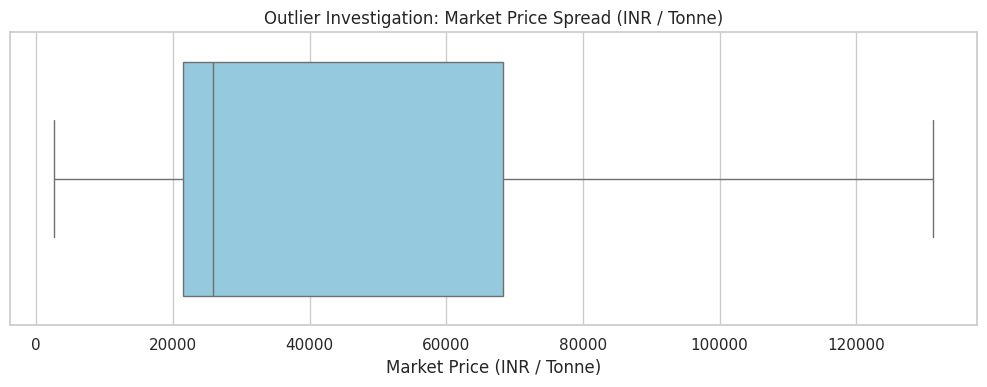

In [ ]:
# Outlier Investigation (Option C5)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Market_Price_INR_Tonne'], color='skyblue')
plt.title('Outlier Investigation: Market Price Spread (INR / Tonne)')
plt.xlabel('Market Price (INR / Tonne)')
plt.tight_layout()
plt.show()

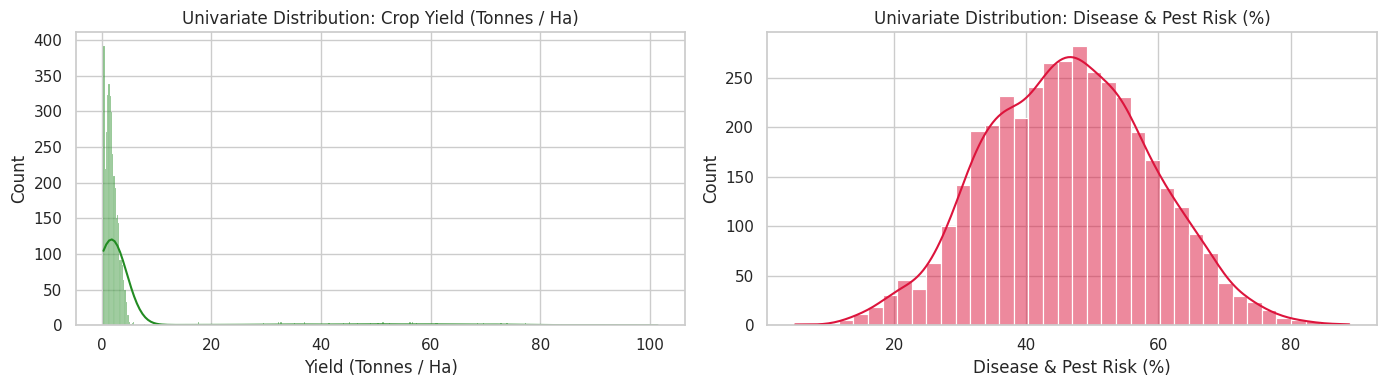

In [ ]:
# Univariate Analysis (Option C2)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['Yield_Tonnes_Ha'], kde=True, color='forestgreen', ax=axes[0])
axes[0].set_title('Univariate Distribution: Crop Yield (Tonnes / Ha)')
axes[0].set_xlabel('Yield (Tonnes / Ha)')

sns.histplot(df['Disease_Pest_Risk_pct'], kde=True, color='crimson', ax=axes[1])
axes[1].set_title('Univariate Distribution: Disease & Pest Risk (%)')
axes[1].set_xlabel('Disease & Pest Risk (%)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2014/2241775880.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Crop', y='Market_Price_INR_Tonne', hue='Season', ci=None)


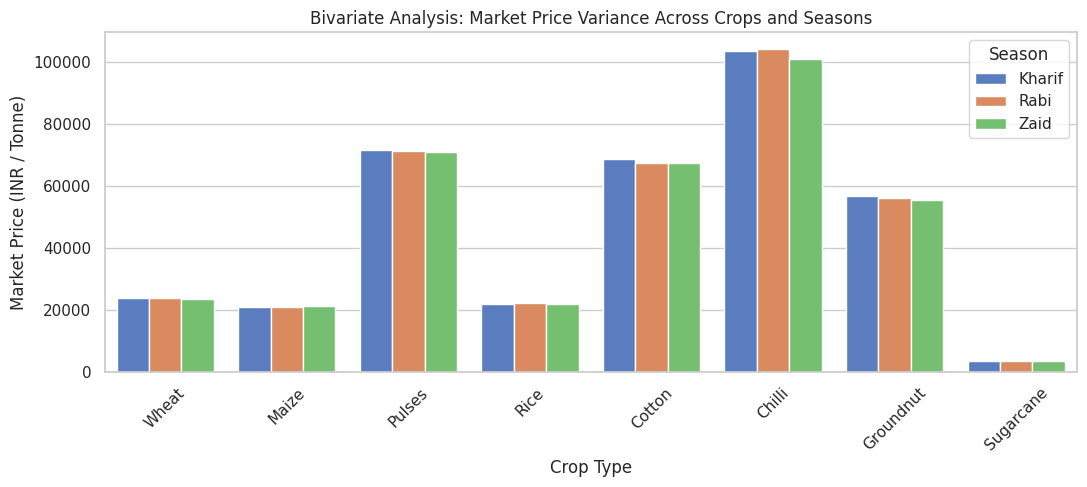

In [ ]:
# Bivariate Analysis (Option A1)
plt.figure(figsize=(11, 5))
sns.barplot(data=df, x='Crop', y='Market_Price_INR_Tonne', hue='Season', ci=None)
plt.title('Bivariate Analysis: Market Price Variance Across Crops and Seasons')
plt.xlabel('Crop Type')
plt.ylabel('Market Price (INR / Tonne)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

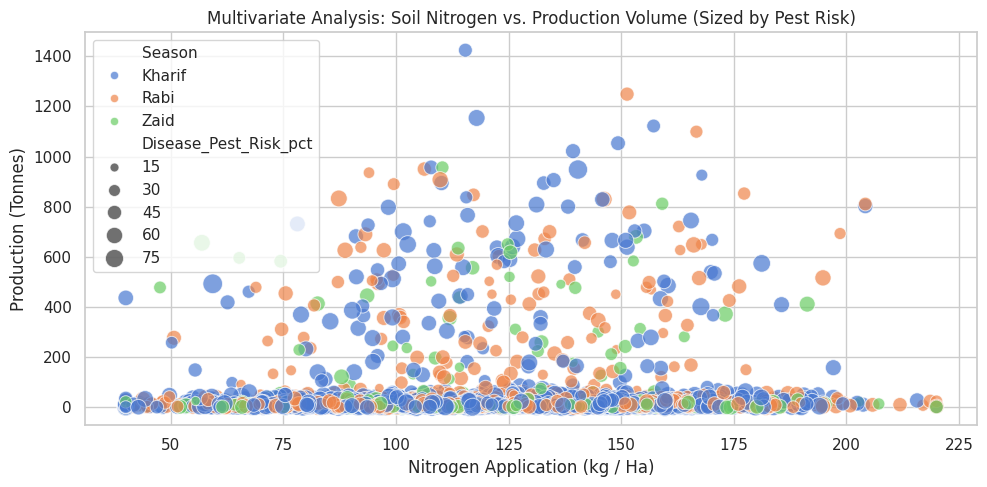

In [ ]:
# Multivariate Analysis (Option C3 & A5)
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, x='Nitrogen_kg_ha', y='Production_Tonnes',
    hue='Season', size='Disease_Pest_Risk_pct', sizes=(20, 200), alpha=0.7
)
plt.title('Multivariate Analysis: Soil Nitrogen vs. Production Volume (Sized by Pest Risk)')
plt.xlabel('Nitrogen Application (kg / Ha)')
plt.ylabel('Production (Tonnes)')
plt.tight_layout()
plt.show()

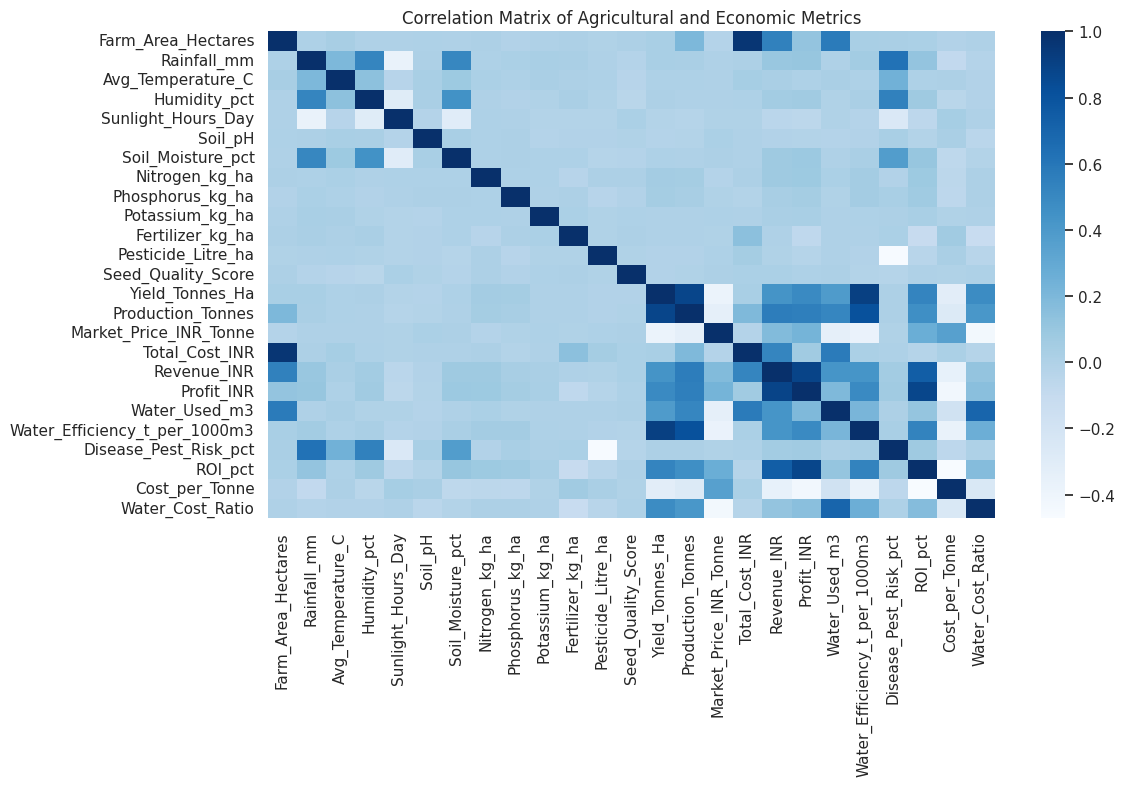

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), cmap='Blues', annot=False)
plt.title('Correlation Matrix of Agricultural and Economic Metrics')
plt.tight_layout()
plt.show()

# 5. Seasonal Comparative & Statistical Analysis

In [ ]:
# Aggregated Seasonal Comparison
print("--- SEASONAL PERFORMANCE SUMMARY ---")
seasonal_summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Market_Price_INR_Tonne', 'ROI_pct', 'Disease_Pest_Risk_pct']].mean()
display(seasonal_summary)

--- SEASONAL PERFORMANCE SUMMARY ---


,Yield_Tonnes_Ha,Market_Price_INR_Tonne,ROI_pct,Disease_Pest_Risk_pct
Season,,,,
Kharif,5.628612,44850.906127,35.450472,54.467903
Rabi,5.039435,44747.974800,17.597725,40.482114
Zaid,4.641313,44212.033670,-2.467137,38.216667


/tmp/ipykernel_2014/3233835504.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Seed_Quality_Score', y='Market_Price_INR_Tonne', hue='Crop', ci=None)


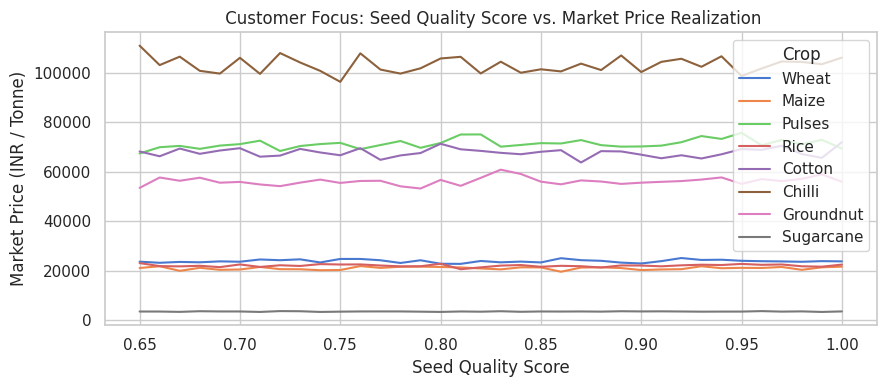

In [ ]:
# Customer Focus (Seed Quality Impact on Market Value)
plt.figure(figsize=(9, 4))
sns.lineplot(data=df, x='Seed_Quality_Score', y='Market_Price_INR_Tonne', hue='Crop', ci=None)
plt.title(' Customer Focus: Seed Quality Score vs. Market Price Realization')
plt.xlabel('Seed Quality Score')
plt.ylabel('Market Price (INR / Tonne)')
plt.tight_layout()
plt.show()

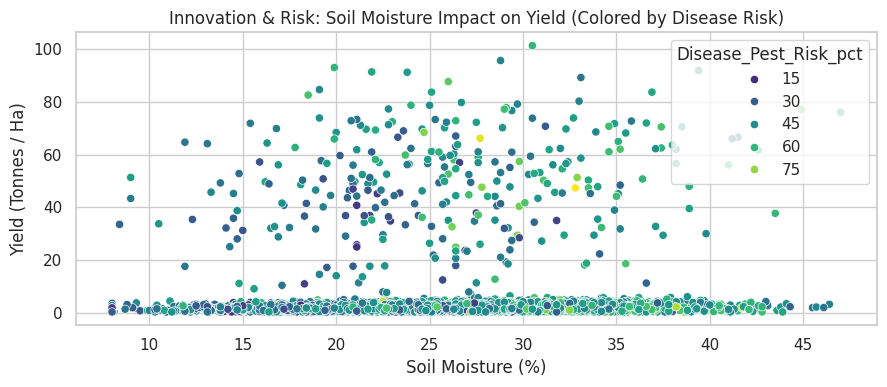

In [ ]:
# Innovation & Risk ( Resource Interaction and Disease Spread)
plt.figure(figsize=(9, 4))
sns.scatterplot(data=df, x='Soil_Moisture_pct', y='Yield_Tonnes_Ha', hue='Disease_Pest_Risk_pct', palette='viridis')
plt.title('Innovation & Risk: Soil Moisture Impact on Yield (Colored by Disease Risk)')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes / Ha)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2014/555099292.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='State', y='Water_Efficiency_t_per_1000m3', hue='Season', ci=None)


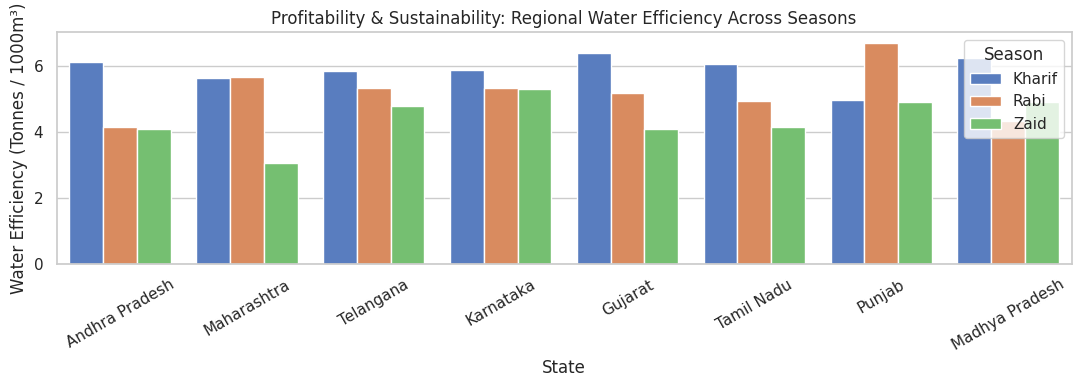

In [ ]:
# Profitability & Sustainability (Water Efficiency Across Regions)
plt.figure(figsize=(11, 4))
sns.barplot(data=df, x='State', y='Water_Efficiency_t_per_1000m3', hue='Season', ci=None)
plt.title('Profitability & Sustainability: Regional Water Efficiency Across Seasons')
plt.xlabel('State')
plt.ylabel('Water Efficiency (Tonnes / 1000m³)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Statistical Significance Testing Across Seasons (ANOVA / Kruskal-Wallis)
from scipy import stats

print("--- STATISTICAL SIGNIFICANCE TESTING ACROSS SEASONS ---")

# Test 1: Yield Variance Across Seasons
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat_yield, p_val_yield = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"1. One-Way ANOVA (Yield across Seasons): F-Statistic = {f_stat_yield:.4f}, p-value = {p_val_yield:.4e}")

# Test 2: Disease & Pest Risk Variance Across Seasons
kharif_pest = df[df['Season'] == 'Kharif']['Disease_Pest_Risk_pct']
rabi_pest = df[df['Season'] == 'Rabi']['Disease_Pest_Risk_pct']
zaid_pest = df[df['Season'] == 'Zaid']['Disease_Pest_Risk_pct']

kw_stat_pest, p_val_pest = stats.kruskal(kharif_pest, rabi_pest, zaid_pest)
print(f"2. Kruskal-Wallis (Pest Risk across Seasons): H-Statistic = {kw_stat_pest:.4f}, p-value = {p_val_pest:.4e}")

# Conclusion on statistical significance
if p_val_yield < 0.05:
    print("✅ Result: Significant statistical difference in yield across farming seasons (p < 0.05).")
else:
    print("ℹ️ Result: No statistically significant yield difference detected across seasons.")

--- STATISTICAL SIGNIFICANCE TESTING ACROSS SEASONS ---
1. One-Way ANOVA (Yield across Seasons): F-Statistic = 1.5439, p-value = 2.1368e-01
2. Kruskal-Wallis (Pest Risk across Seasons): H-Statistic = 1430.9101, p-value = 1.9134e-311
ℹ️ Result: No statistically significant yield difference detected across seasons.


# 6. Visualizations & Pattern Discovery

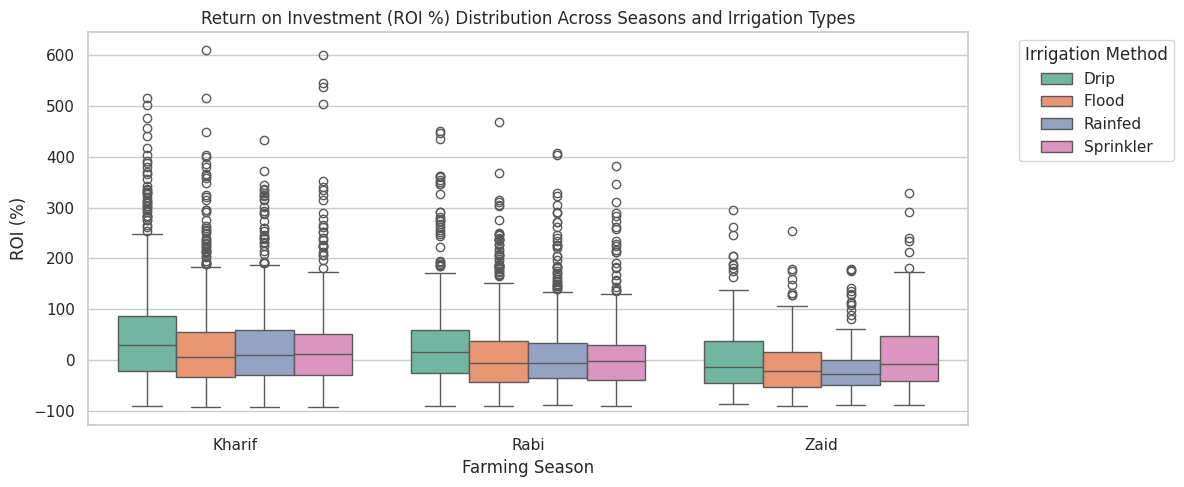

In [ ]:
# Comparative Multi-Panel Visualizations

# Chart 1: ROI % Distribution by Season and Irrigation Method
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Season', y='ROI_pct', hue='Irrigation_Method', palette='Set2')
plt.title('Return on Investment (ROI %) Distribution Across Seasons and Irrigation Types')
plt.xlabel('Farming Season')
plt.ylabel('ROI (%)')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

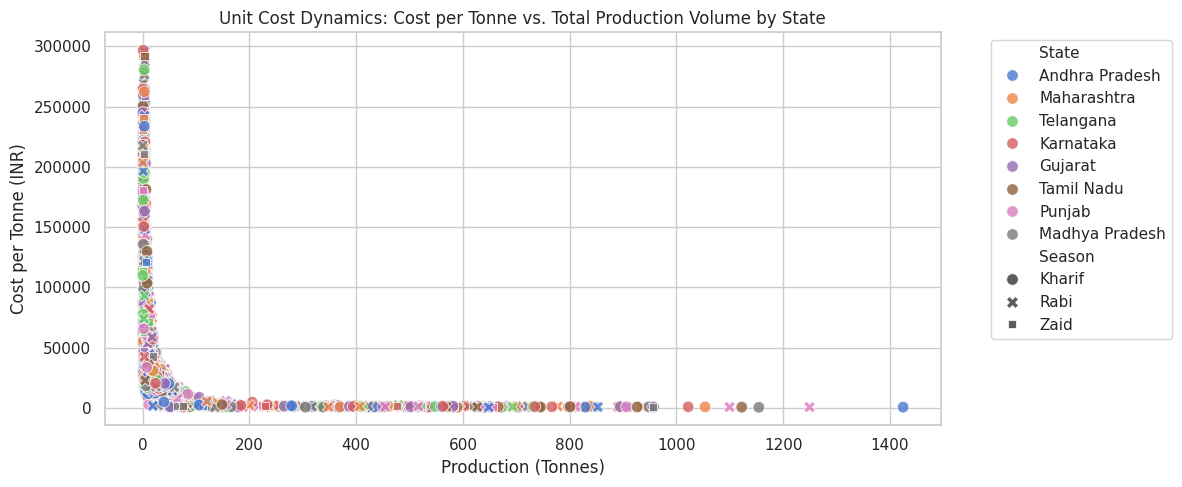

In [ ]:
# Chart 2: Cost per Tonne vs. Production Volume by State
plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df, x='Production_Tonnes', y='Cost_per_Tonne',
    hue='State', style='Season', alpha=0.8, s=70
)
plt.title('Unit Cost Dynamics: Cost per Tonne vs. Total Production Volume by State')
plt.xlabel('Production (Tonnes)')
plt.ylabel('Cost per Tonne (INR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

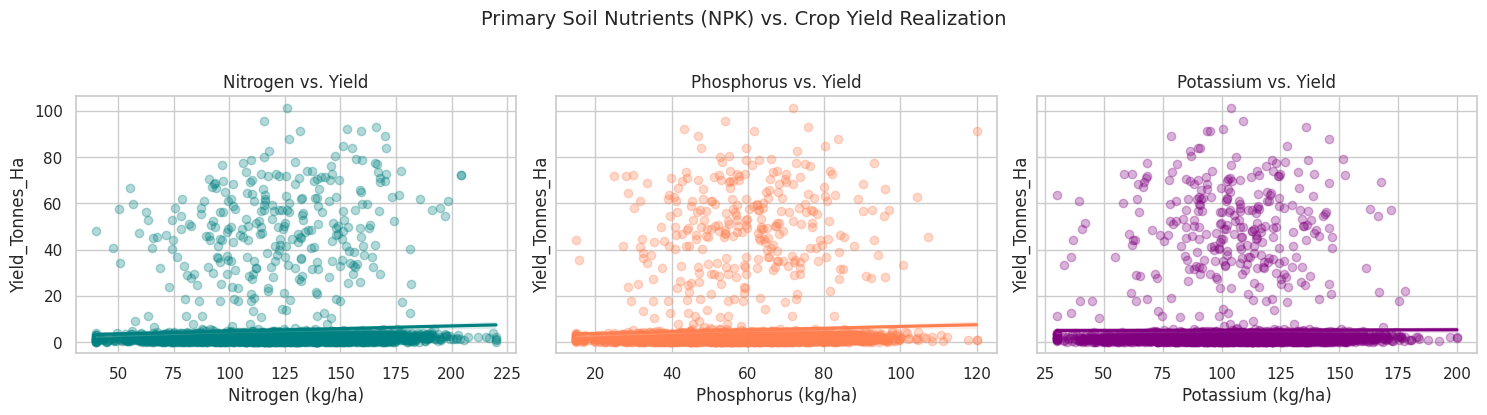

In [ ]:
# Chart 3: Soil Nutrient Ratio Matrix (NPK vs Yield)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

sns.regplot(data=df, x='Nitrogen_kg_ha', y='Yield_Tonnes_Ha', ax=axes[0], color='teal', scatter_kws={'alpha':0.3})
axes[0].set_title('Nitrogen vs. Yield')
axes[0].set_xlabel('Nitrogen (kg/ha)')

sns.regplot(data=df, x='Phosphorus_kg_ha', y='Yield_Tonnes_Ha', ax=axes[1], color='coral', scatter_kws={'alpha':0.3})
axes[1].set_title('Phosphorus vs. Yield')
axes[1].set_xlabel('Phosphorus (kg/ha)')

sns.regplot(data=df, x='Potassium_kg_ha', y='Yield_Tonnes_Ha', ax=axes[2], color='purple', scatter_kws={'alpha':0.3})
axes[2].set_title('Potassium vs. Yield')
axes[2].set_xlabel('Potassium (kg/ha)')

plt.suptitle('Primary Soil Nutrients (NPK) vs. Crop Yield Realization', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Grouping dataset by Season to evaluate Key Performance Indicators (KPIs)
seasonal_summary = df.groupby('Season').agg(
    Farm_Count=('Farm_ID', 'count'),
    Avg_Yield_Tonnes_Ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temp_C=('Avg_Temperature_C', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Total_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_ROI_pct=('ROI_pct', 'mean'),
    Avg_Pest_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2).reset_index()

print("--- SEASONAL PERFORMANCE BREAKDOWN ---")
display(seasonal_summary)

--- SEASONAL PERFORMANCE BREAKDOWN ---


,Season,Farm_Count,Avg_Yield_Tonnes_Ha,Avg_Rainfall_mm,Avg_Temp_C,Avg_Water_Used_m3,Avg_Total_Cost_INR,Avg_Revenue_INR,Avg_Profit_INR,Avg_ROI_pct,Avg_Pest_Risk_pct
0,Kharif,1779,5.63,849.20,28.45,6102.20,531804.41,710719.06,178914.65,35.45,54.47
1,Rabi,1627,5.04,437.62,23.49,5846.99,513836.58,601526.05,87689.47,17.60,40.48
2,Zaid,594,4.64,304.65,31.04,6419.89,543976.73,519171.90,-24804.82,-2.47,38.22


In [ ]:
# Granular Analysis: Performance by Crop within each Season
crop_seasonal_summary = df.groupby(['Season', 'Crop']).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_ROI=('ROI_pct', 'mean'),
    Avg_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2).reset_index()

print("\n--- CROP-WISE SEASONAL BREAKDOWN ---")
display(crop_seasonal_summary.head(10))


--- CROP-WISE SEASONAL BREAKDOWN ---


,Season,Crop,Avg_Yield,Avg_Profit,Avg_ROI,Avg_Pest_Risk
0,Kharif,Chilli,1.73,954380.42,173.73,52.81
1,Kharif,Cotton,1.37,216999.55,43.35,54.24
2,Kharif,Groundnut,1.48,108265.44,27.21,54.28
3,Kharif,Maize,2.97,-39332.67,-6.07,54.82
4,Kharif,Pulses,1.04,43338.90,13.42,54.96
5,Kharif,Rice,2.70,-64903.40,-10.01,54.25
6,Kharif,Sugarcane,53.46,1000790.81,187.15,54.02
7,Kharif,Wheat,2.25,-105871.87,-18.64,55.58
8,Rabi,Chilli,1.47,638572.50,133.65,40.59
9,Rabi,Cotton,1.20,107343.59,22.54,41.54


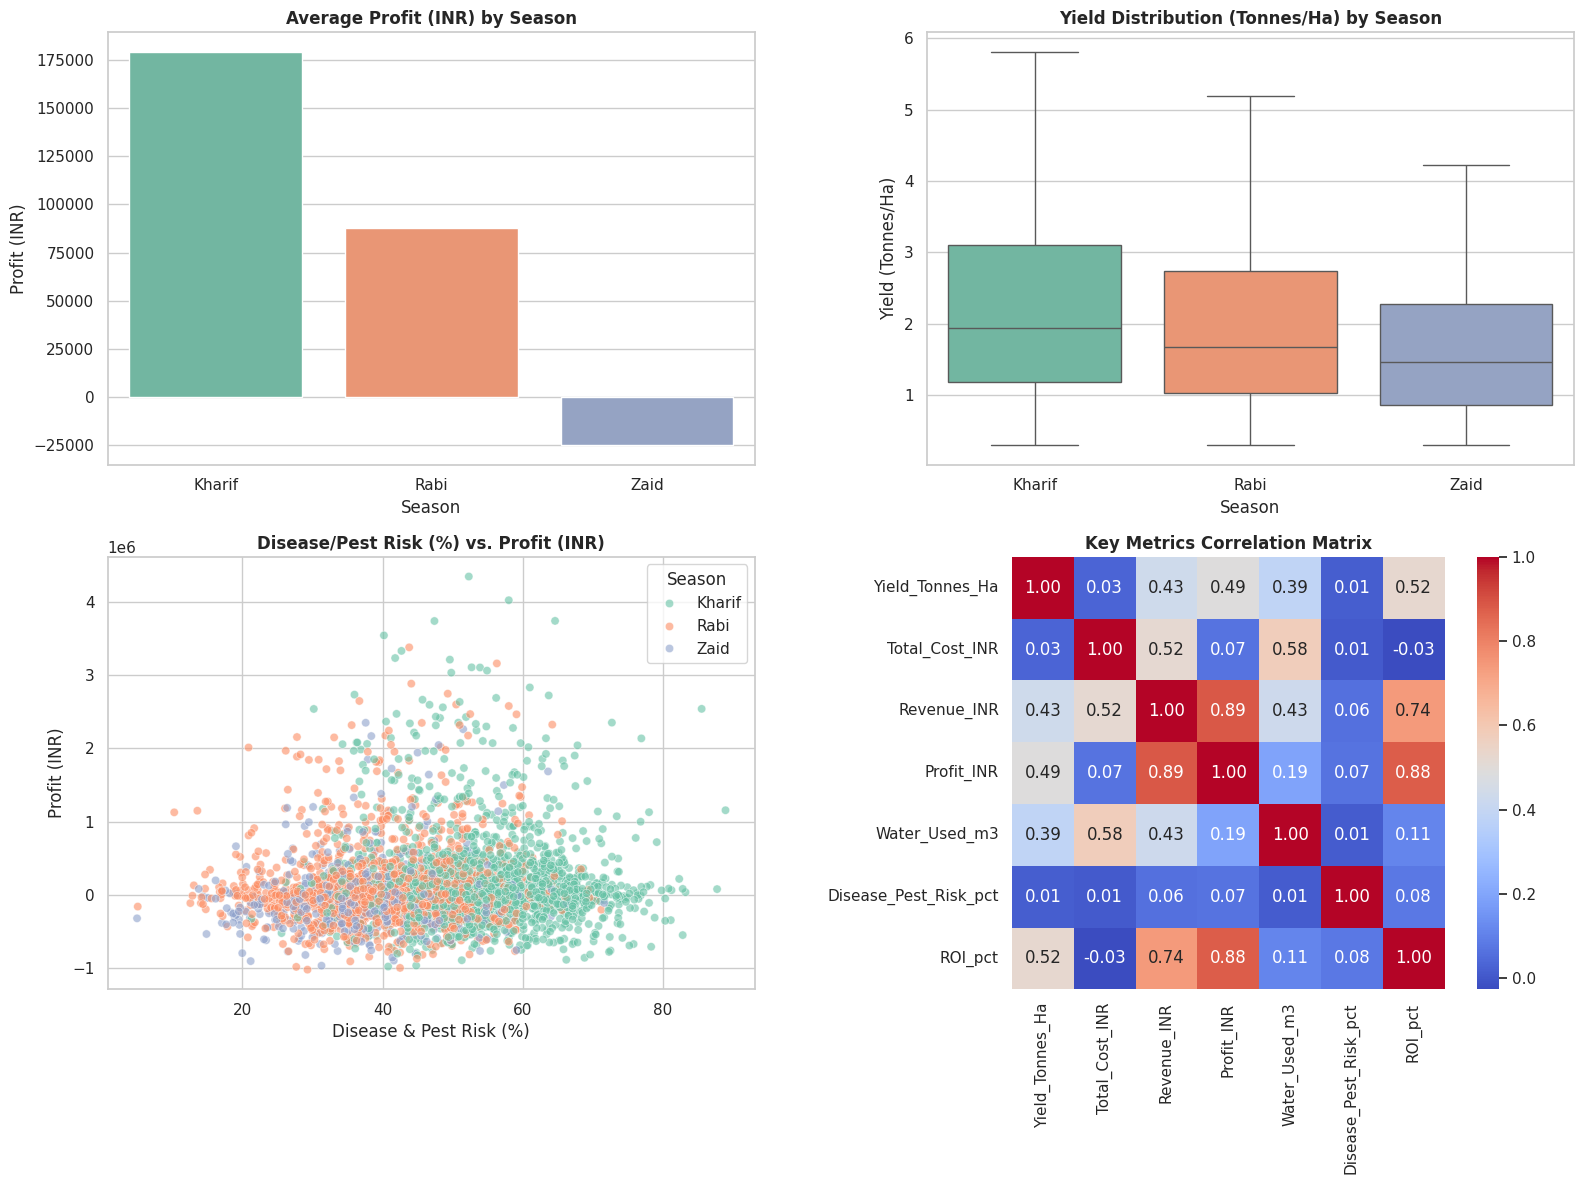

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Average Profit by Season (Bar Plot)
sns.barplot(
    data=df, x='Season', y='Profit_INR', ax=axes[0, 0],
    hue='Season', estimator=np.mean, errorbar=None, palette='Set2'
)
axes[0, 0].set_title('Average Profit (INR) by Season', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Profit (INR)')

# Chart 2: Yield Distribution across Seasons (Box Plot)
sns.boxplot(
    data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0, 1],
    hue='Season', palette='Set2', showfliers=False
)
axes[0, 1].set_title('Yield Distribution (Tonnes/Ha) by Season', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Yield (Tonnes/Ha)')

# Chart 3: Disease & Pest Risk vs. Profit colored by Season (Scatter Plot)
sns.scatterplot(
    data=df, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season',
    alpha=0.6, ax=axes[1, 0], palette='Set2'
)
axes[1, 0].set_title('Disease/Pest Risk (%) vs. Profit (INR)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Disease & Pest Risk (%)')
axes[1, 0].set_ylabel('Profit (INR)')

# Chart 4: Correlation Matrix
numeric_cols = [
    'Yield_Tonnes_Ha', 'Total_Cost_INR', 'Revenue_INR',
    'Profit_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct', 'ROI_pct'
]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
    ax=axes[1, 1], cbar=True, square=True
)
axes[1, 1].set_title('Key Metrics Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Section 7: Recommendations & Conclusion

## 14. Key Insights

1. **Yield is different across seasons, but the difference is not statistically significant.**
   The average yield varies between Kharif, Rabi, and Zaid, but the ANOVA test shows that the difference is not statistically significant.

2. **Disease and pest risk changes significantly by season.**
   The Kruskal-Wallis test shows a significant difference in disease and pest risk across seasons.

3. **NPK and crop production are related.**
   The analysis shows the relationship between nitrogen, phosphorus, potassium, and crop yield.

4. **ROI changes with irrigation methods and seasons.**
   Different irrigation methods show different ROI patterns across seasons.

5. **Production cost varies between states.**
   Cost per tonne changes across states and production levels.

6. **Water efficiency differs across states and seasons.**
   Some state-season combinations use water more efficiently than others.

7. **Seed quality is related to market price.**
   The analysis shows a relationship between seed quality and market price for different crops.

8. **Soil moisture is related to crop yield and disease risk.**
   The analysis shows how soil moisture and disease risk appear together with crop yield.

9. **Revenue, cost, profit, and ROI are strongly connected.**
   The correlation analysis shows important relationships between agricultural and financial measures.


## 15. Recommendations

1. **Plan pest and disease management according to the season** because risk changes significantly between seasons.

2. **Use fertilizer carefully** and study NPK levels along with crop yield before increasing fertilizer use.

3. **Compare irrigation methods by season** and consider ROI when selecting an irrigation method.

4. **Investigate states with high cost per tonne** to find possible areas for reducing production costs.

5. **Improve water efficiency** in state-season combinations where water use is less efficient.

6. **Consider seed quality when planning crop production**, especially where higher quality is linked with better market prices.

7. **Monitor soil moisture and disease risk together** when making irrigation decisions.

## Limitations

- The analysis shows relationships between variables but does not prove cause and effect.
- The dataset does not include all factors that may affect agricultural performance.
- Some comparisons may be affected by differences in crop type, state, farm size, and other conditions.
- The analysis is based on the available dataset and may not represent all agricultural conditions.

## 16. Conclusion

The analysis shows that agricultural performance changes by season, state, crop, and irrigation method. Yield, pest risk, ROI, cost, and water efficiency all show differences. The results show useful relationships, but they do not prove cause and effect. Further study can help improve farming decisions.


## 17. Project Checklist

- [x] Dataset loaded successfully
- [x] Top 5 rows checked
- [x] Dataset shape and structure examined
- [x] Data types checked
- [x] Missing values checked and handled
- [x] Duplicate records checked and handled
- [x] New features created (ROI, Cost per Tonne, Water-Cost Ratio)
- [x] Descriptive statistical analysis completed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparison completed
- [x] Statistical testing completed (ANOVA and Kruskal-Wallis)
- [x] analyses completed
- [x] insights documented
- [x] Evidence-based recommendations provided
- [x] Limitations discussed
- [x] Final conclusion provided